In [1]:
import pandas as pd

In [3]:
dados = pd.read_excel('/content/drive/MyDrive/cursos - materiais /Analise de Dados | meus primeiros passos em python/analise_dados_mod7_(1) (1).xlsx')

In [4]:
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)']

In [5]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762


In [6]:
lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena']

In [7]:
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]

In [8]:
dados['NAO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x!= 'Branca' else 0)

In [9]:
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

In [10]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.', '')

In [11]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [12]:
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0)

In [13]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

,Qual o principal motivo da sua insatisfação com a empresa atual?
1,0
2,0
7,1
10,0
26,1
...,...
4227,0
4234,1
4238,0
4240,1


In [14]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

In [15]:
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x== 'Não tenho graduação formal' else
                                                          1 if x== 'Estudante de Graduação' else
                                                          2 if x== 'Graduação/Bacharelado' else
                                                          3 if x== 'Pós-graduação' else
                                                          4 if x== 'Mestrado' else
                                                          5 if x== 'Doutorado ou Phd' else -1)

In [16]:
dados = dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA',
               'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL']]

In [17]:
print(dados.columns)

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL'],
      dtype='object')


In [18]:
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

In [19]:
x = dados.drop('SALARIO', axis=1)

In [20]:
y = dados['SALARIO']

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
x_train_scaled = scaler.fit_transform(x_train)

In [27]:
x_test_scaled = scaler.fit_transform(x_test)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [32]:
from sklearn.impute import SimpleImputer

# Impute NaN values in x_train_scaled and x_test_scaled
imputer = SimpleImputer(strategy='mean')

x_train_scaled_imputed = imputer.fit_transform(x_train_scaled)
x_test_scaled_imputed = imputer.transform(x_test_scaled)

model.fit(x_train_scaled_imputed, y_train)

LinearRegression()

In [33]:
model.predict(x_test_scaled_imputed)

array([21605.92246582, 16505.75500965,  3105.53546165,  3753.20558108,
       17309.90446441,  6795.54768788,  3977.21275927, 13016.68090695,
        2956.56834094, 11161.29021772,  8692.67023629,  8681.20363191,
        8000.65831364, 18107.4283472 , 17962.92873839,  8355.64716578,
       10695.90068731,  6272.99278548,  4484.66028737, 14560.89651865,
        7001.27586055, 10998.82887874, 18207.93708477,  9155.64541673,
        8892.69961216, 22701.22338898,  9842.03491311, 11597.19982505,
       10000.75655917, 19821.58599662, 12948.11892286, 12687.95116925,
       18687.60006487,  5487.96464587,  5677.70044806,  4808.2479145 ,
       16373.40226472,  9513.56615821, 11489.82271871,  3040.96120115,
        7832.80228366,  8500.37797201,  6322.61324292,  6268.23970921,
       13148.3028544 , 11203.43864589, 14165.06477806,  2418.5828834 ,
        5660.23022291, 23022.56296877,  8862.60810669, 10706.28382151,
       20392.40085067,  8977.10097535, 17882.65836186, 13000.75510421,
      

In [34]:
y_pred = model.predict(x_test_scaled_imputed)

In [38]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [36]:
mse = mean_squared_error(y_test, y_pred)

In [37]:
mse

23666985.43217396

In [39]:
mae = mean_absolute_error(y_test, y_pred)

In [40]:
mae

3348.9324495271894

In [41]:
r2 = r2_score(y_test, y_pred)

In [42]:
r2

0.5171205521962196

In [43]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

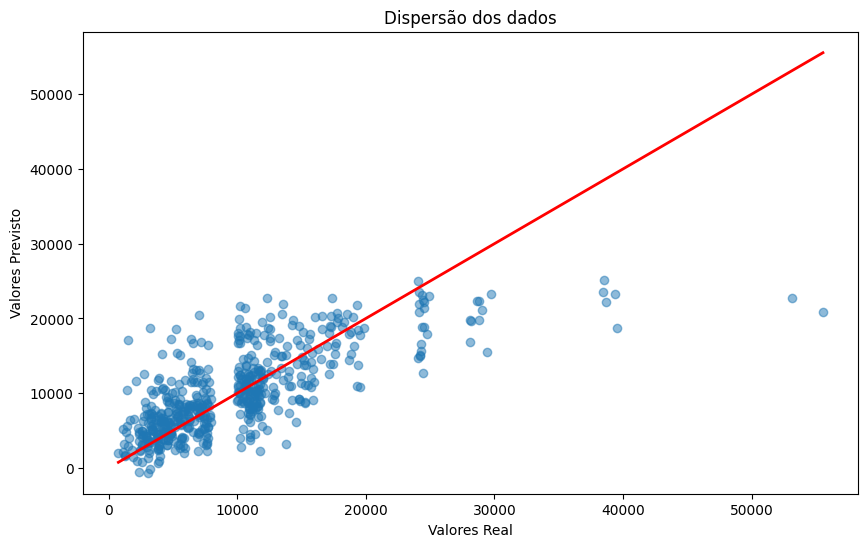

In [45]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Valores Real')
plt.ylabel('Valores Previsto')
plt.title('Dispersão dos dados')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.show

In [47]:
nomes_atributos = x_train.columns

In [48]:
coefs = pd.DataFrame( model.coef_, columns=["coeficientes"], index=nomes_atributos)

In [49]:
coefs

,coeficientes
IDADE,-125.507950
NAO_BRANCA,-428.630664
TEMPO_EXPERIENCIA,2013.160304
INSATISFACAO,-396.085884
NIVEL DE ENSINO,855.975195
NUMERO DE FUNCIONARIOS,834.393841
GENERO_Masculino,553.985476
GENERO_Prefiro não informar,82.641249
SETOR_Educação,-165.101136
SETOR_Entretenimento ou Esportes,236.602504


In [51]:
coefs = coefs.sort_values(by = 'coeficientes', ascending=False)

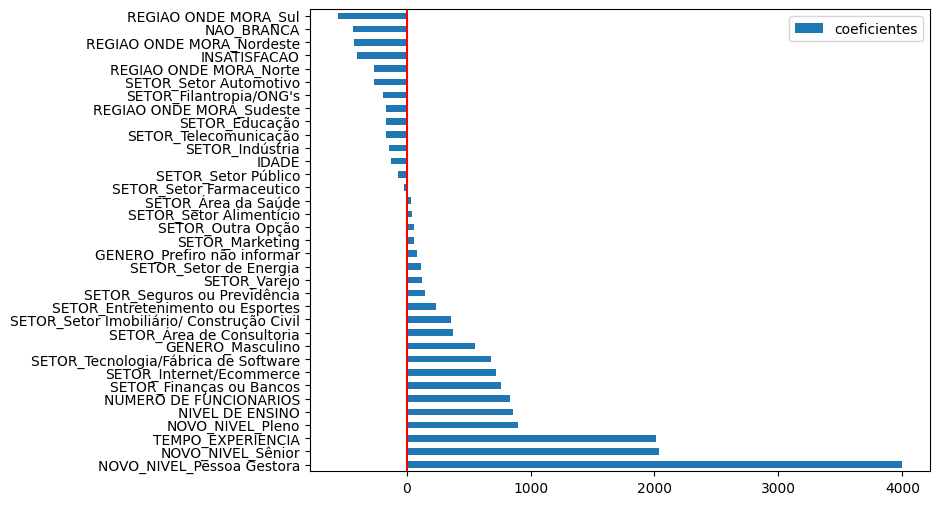

In [52]:
coefs.plot.barh(figsize=(8,6))
plt.axvline(x=0, color='red')